Position-wise Feed-Forward Networks

In [1]:
import torch
import torch.nn as nn

In [3]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.linear_1 = nn.Linear(in_features=d_model, out_features=d_ff) # w_1 and b_1
        self.linear_2 = nn.Linear(in_features=d_ff, out_features=d_model) # w_2 and b_2
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        h1 = self.linear_1(x)
        h2 = self.dropout(torch.relu(h1))
        return self.linear_2(h2)

In [4]:
batch_size, seq_len, d_model, h, d_ff = 2, 10, 512, 8, 2048

FFN = PositionwiseFeedForward(d_model, d_ff)
x = torch.randn(batch_size, seq_len, d_model)
output = FFN(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

Input shape: torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])


VISUALIZATION 2: Model Architecture (torchview)
✓ Architecture diagram saved as 'position_wise_feed_forward_arch.png'
✓ Model graph object created


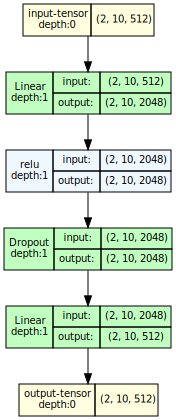

In [5]:
from torchview import draw_graph
# ============================================================
# Visualization 2: Model Architecture with torchview
# ============================================================
print("=" * 60)
print("VISUALIZATION 2: Model Architecture (torchview)")
print("=" * 60)
try:
    model_graph = draw_graph(
        FFN,
        input_data=x,
        graph_dir='TB', # Horizontal layout
                        # 'TB'	Top to Bottom	Vertical (default)
                        # 'LR'	Left to Right	Horizontal
                        # 'BT'	Bottom to Top	Vertical (reversed)
                        # 'RL'	Right to Left	Horizontal (reversed)
        expand_nested=True,
        graph_name='position-wise-feed-forward net',
        save_graph=True,
        filename='position_wise_feed_forward_arch',
        directory='.'
    )
    
    print("✓ Architecture diagram saved as 'position_wise_feed_forward_arch.png'")
    print(f"✓ Model graph object created")
    
    # Display visual graph
    display(model_graph.visual_graph)
    
except Exception as e:
    print(f"✗ Failed to generate architecture diagram: {e}")

print()

✓ Visualization saved as 'ffn_architecture.png'


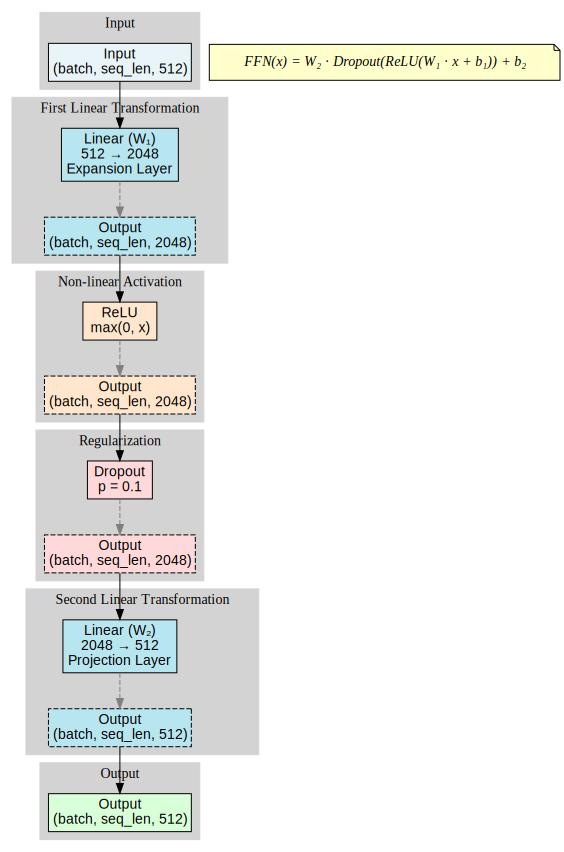

[36124:36124:0415/112231.244477:ERROR:ui/ozone/platform/x11/ozone_platform_x11.cc:256] Missing X server or $DISPLAY
[36124:36124:0415/112231.244507:ERROR:ui/aura/env.cc:246] The platform failed to initialize.  Exiting.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from graphviz import Digraph

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        return self.w_2(self.dropout(F.relu(self.w_1(x))))

def visualize_ffn_architecture(d_model=512, d_ff=2048, dropout=0.1):
    """Create detailed visualization of FFN architecture"""
    
    dot = Digraph(comment='Position-wise Feed-Forward Network', format='png')
    dot.attr(rankdir='TB', size='10,12')
    dot.attr('node', shape='box', style='filled', fontname='Arial')
    
    # Color scheme
    input_color = '#E8F4F8'
    linear_color = '#B8E6F0'
    activation_color = '#FFE6CC'
    dropout_color = '#FFD9D9'
    output_color = '#D9FFD9'
    
    # Input
    with dot.subgraph(name='cluster_input') as c:
        c.attr(label='Input', style='filled', color='lightgrey')
        c.node('input', f'Input\n(batch, seq_len, {d_model})', fillcolor=input_color)
    
    # First Linear Layer
    with dot.subgraph(name='cluster_linear1') as c:
        c.attr(label='First Linear Transformation', style='filled', color='lightgrey')
        c.node('linear1', f'Linear (W₁)\n{d_model} → {d_ff}\nExpansion Layer', fillcolor=linear_color)
        c.node('after_linear1', f'Output\n(batch, seq_len, {d_ff})', fillcolor=linear_color, style='filled,dashed')
    
    # ReLU Activation
    with dot.subgraph(name='cluster_relu') as c:
        c.attr(label='Non-linear Activation', style='filled', color='lightgrey')
        c.node('relu', f'ReLU\nmax(0, x)', fillcolor=activation_color)
        c.node('after_relu', f'Output\n(batch, seq_len, {d_ff})', fillcolor=activation_color, style='filled,dashed')
    
    # Dropout
    with dot.subgraph(name='cluster_dropout') as c:
        c.attr(label='Regularization', style='filled', color='lightgrey')
        c.node('dropout', f'Dropout\np = {dropout}', fillcolor=dropout_color)
        c.node('after_dropout', f'Output\n(batch, seq_len, {d_ff})', fillcolor=dropout_color, style='filled,dashed')
    
    # Second Linear Layer
    with dot.subgraph(name='cluster_linear2') as c:
        c.attr(label='Second Linear Transformation', style='filled', color='lightgrey')
        c.node('linear2', f'Linear (W₂)\n{d_ff} → {d_model}\nProjection Layer', fillcolor=linear_color)
        c.node('after_linear2', f'Output\n(batch, seq_len, {d_model})', fillcolor=linear_color, style='filled,dashed')
    
    # Output
    with dot.subgraph(name='cluster_output') as c:
        c.attr(label='Output', style='filled', color='lightgrey')
        c.node('output', f'Output\n(batch, seq_len, {d_model})', fillcolor=output_color)
    
    # Connections
    dot.edge('input', 'linear1')
    dot.edge('linear1', 'after_linear1', style='dashed', color='gray')
    dot.edge('after_linear1', 'relu')
    dot.edge('relu', 'after_relu', style='dashed', color='gray')
    dot.edge('after_relu', 'dropout')
    dot.edge('dropout', 'after_dropout', style='dashed', color='gray')
    dot.edge('after_dropout', 'linear2')
    dot.edge('linear2', 'after_linear2', style='dashed', color='gray')
    dot.edge('after_linear2', 'output')
    
    # Add formula
    dot.node('formula', 
             'FFN(x) = W₂ · Dropout(ReLU(W₁ · x + b₁)) + b₂',
             shape='note', fillcolor='#FFFFCC', fontname='Times-Italic')
    
    return dot

# Create visualization
dot = visualize_ffn_architecture(d_model=512, d_ff=2048, dropout=0.1)
dot.render('ffn_architecture', view=True, cleanup=True)
print("✓ Visualization saved as 'ffn_architecture.png'")
dot
